# 🧪 Test OpenAI và Xiaomi MiMo Cloud APIs

Notebook này gọi trực tiếp hai Cloud API được cấu hình trong file `.env` của repo:

- OpenAI: `OPENAI_API_KEY`, model `gpt-4o-mini`
- Xiaomi MiMo: `MIMO_API_KEY`, `MIMO_API_BASE`, model `mimo-v2.5-pro`

API key không được in ra màn hình. Cấu trúc test tương tự `Test_LocalAPI.ipynb`: kiểm tra kết nối, chat, system prompt, streaming và benchmark.

In [3]:
# Chạy cell này nếu kernel hiện tại chưa có package cần thiết.
%pip install -q requests python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [4]:
import json
import os
import time
from pathlib import Path

import requests
from dotenv import load_dotenv


def find_repo_env() -> Path:
    """Tìm .env khi notebook được mở từ root repo hoặc thư mục Notebooks."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for directory in candidates:
        env_path = directory / ".env"
        if env_path.is_file():
            return env_path
    raise FileNotFoundError("Không tìm thấy file .env trong thư mục hiện tại hoặc các thư mục cha.")


ENV_PATH = find_repo_env()
load_dotenv(ENV_PATH, override=False)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "").strip()
MIMO_API_KEY = os.getenv("MIMO_API_KEY", "").strip()
MIMO_API_BASE = os.getenv("MIMO_API_BASE", "").strip().rstrip("/")

print(f"Đã nạp cấu hình từ: {ENV_PATH}")
print(f"OPENAI_API_KEY: {'đã cấu hình' if OPENAI_API_KEY else 'chưa cấu hình'}")
print(f"MIMO_API_KEY:   {'đã cấu hình' if MIMO_API_KEY else 'chưa cấu hình'}")
print(f"MIMO_API_BASE:  {MIMO_API_BASE or 'chưa cấu hình'}")

Đã nạp cấu hình từ: /home/jkl0909/Code/llm/VLLM-PD/.env
OPENAI_API_KEY: đã cấu hình
MIMO_API_KEY:   đã cấu hình
MIMO_API_BASE:  https://token-plan-sgp.xiaomimimo.com/v1


In [5]:
def test_chat_completion(provider, api_base, api_key, model):
    """Gửi một yêu cầu chat completion và trả về kết quả test."""
    if not api_key:
        return {"provider": provider, "ok": False, "error": "API key chưa được cấu hình"}
    if not api_base:
        return {"provider": provider, "ok": False, "error": "API base chưa được cấu hình"}

    url = f"{api_base.rstrip('/')}/chat/completions"
    payload = {
        "model": model,
        "messages": [
            {
                "role": "user",
                "content": "Trả lời đúng một câu ngắn: API đang hoạt động.",
            }
        ],
        "temperature": 0,
        "max_tokens": 40,
    }

    try:
        response = requests.post(
            url,
            headers={
                "Authorization": f"Bearer {api_key}",
                "Content-Type": "application/json",
            },
            json=payload,
            timeout=120,
        )
        response.raise_for_status()
        data = response.json()
        return {
            "provider": provider,
            "ok": True,
            "status_code": response.status_code,
            "model": data.get("model", model),
            "answer": data["choices"][0]["message"]["content"],
            "usage": data.get("usage", {}),
        }
    except requests.RequestException as exc:
        response = getattr(exc, "response", None)
        detail = response.text[:1000] if response is not None else str(exc)
        return {
            "provider": provider,
            "ok": False,
            "status_code": response.status_code if response is not None else None,
            "error": detail,
        }
    except (KeyError, IndexError, ValueError) as exc:
        return {"provider": provider, "ok": False, "error": f"Response không hợp lệ: {exc}"}


def print_result(result):
    icon = "OK" if result["ok"] else "FAILED"
    print(f"[{icon}] {result['provider']}")
    if result["ok"]:
        print(f"HTTP status: {result['status_code']}")
        print(f"Model:       {result['model']}")
        print(f"Trả lời:     {result['answer']}")
        print(f"Token usage: {result['usage']}")
    else:
        print(f"HTTP status: {result.get('status_code')}")
        print(f"Lỗi:         {result['error']}")

## 1. Test OpenAI API

In [6]:
openai_result = test_chat_completion(
    provider="OpenAI",
    api_base="https://api.openai.com/v1",
    api_key=OPENAI_API_KEY,
    model="gpt-4o-mini",
)
print_result(openai_result)

[OK] OpenAI
HTTP status: 200
Model:       gpt-4o-mini-2024-07-18
Trả lời:     API đang hoạt động bình thường.
Token usage: {'prompt_tokens': 21, 'completion_tokens': 7, 'total_tokens': 28, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}


## 2. Test Xiaomi MiMo API

In [7]:
mimo_result = test_chat_completion(
    provider="Xiaomi MiMo",
    api_base=MIMO_API_BASE,
    api_key=MIMO_API_KEY,
    model="mimo-v2.5-pro",
)
print_result(mimo_result)

[OK] Xiaomi MiMo
HTTP status: 200
Model:       mimo-v2.5-pro
Trả lời:     
Token usage: {'completion_tokens': 40, 'prompt_tokens': 264, 'total_tokens': 304, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_tokens_details': {'cached_tokens': 256}}


## 3. Tổng kết

In [8]:
results = [openai_result, mimo_result]
for result in results:
    print(f"{result['provider']:<15}: {'PASS' if result['ok'] else 'FAIL'}")

if all(result["ok"] for result in results):
    print("\nCả hai Cloud API đều hoạt động.")
else:
    print("\nCó API chưa hoạt động. Xem lỗi ở cell tương ứng.")

OpenAI         : PASS
Xiaomi MiMo    : PASS

Cả hai Cloud API đều hoạt động.


## 4. Các bài test mở rộng giống `Test_LocalAPI.ipynb`

In [9]:
# ============================================================
# Cell 4: Kiểm tra kết nối qua GET /models
# ============================================================

PROVIDERS = [
    {
        "name": "OpenAI",
        "api_base": "https://api.openai.com/v1",
        "api_key": OPENAI_API_KEY,
        "model": "gpt-4o-mini",
    },
    {
        "name": "Xiaomi MiMo",
        "api_base": MIMO_API_BASE,
        "api_key": MIMO_API_KEY,
        "model": "mimo-v2.5-pro",
    },
]


def provider_headers(provider):
    return {
        "Authorization": f"Bearer {provider['api_key']}",
        "Content-Type": "application/json",
    }


def check_models(provider):
    try:
        response = requests.get(
            f"{provider['api_base']}/models",
            headers=provider_headers(provider),
            timeout=30,
        )
        response.raise_for_status()
        models = [item.get("id") for item in response.json().get("data", [])]
        print(f"✅ {provider['name']}: HTTP {response.status_code}")
        print(f"   Model test: {provider['model']}")
        print(f"   Tổng model trả về: {len(models)}")
    except requests.RequestException as error:
        print(f"⚠️ {provider['name']} không kiểm tra được /models: {error}")
        if error.response is not None:
            print(error.response.text[:1000])
        print("   Vẫn có thể tiếp tục test /chat/completions.")


for provider in PROVIDERS:
    check_models(provider)
    print("-" * 60)

✅ OpenAI: HTTP 200
   Model test: gpt-4o-mini
   Tổng model trả về: 118
------------------------------------------------------------
✅ Xiaomi MiMo: HTTP 200
   Model test: mimo-v2.5-pro
   Tổng model trả về: 9
------------------------------------------------------------


In [10]:
# ============================================================
# Cell 5: Test chat có system prompt trên cả hai API
# ============================================================

def chat_messages(provider, messages, max_tokens=350):
    payload = {
        "model": provider["model"],
        "messages": messages,
        "temperature": 0.2,
        "max_tokens": max_tokens,
        "stream": False,
    }
    try:
        response = requests.post(
            f"{provider['api_base']}/chat/completions",
            headers=provider_headers(provider),
            json=payload,
            timeout=180,
        )
        response.raise_for_status()
        return response.json()
    except requests.RequestException as error:
        print(f"❌ {provider['name']}: {error}")
        if error.response is not None:
            print(error.response.text[:2000])
        return {}


messages = [
    {
        "role": "system",
        "content": "Bạn là trợ lý AI thông minh, luôn trả lời bằng tiếng Việt, ngắn gọn và dễ hiểu.",
    },
    {
        "role": "user",
        "content": "Hãy giải thích mô hình ngôn ngữ lớn (LLM) là gì cho người mới bắt đầu.",
    },
]

for provider in PROVIDERS:
    print(f"\n{'=' * 18} {provider['name']} {'=' * 18}")
    data = chat_messages(provider, messages)
    if data:
        print(data["choices"][0]["message"]["content"])
        print(f"\nToken usage: {data.get('usage', {})}")


================== OpenAI ==================
Mô hình ngôn ngữ lớn (LLM) là một loại trí tuệ nhân tạo được thiết kế để hiểu và tạo ra văn bản giống như con người. Nó được huấn luyện trên một lượng lớn dữ liệu văn bản, giúp nó nắm bắt ngữ nghĩa, ngữ pháp và cách diễn đạt. LLM có thể trả lời câu hỏi, viết văn bản, tóm tắt thông tin và nhiều ứng dụng khác trong xử lý ngôn ngữ tự nhiên.

Token usage: {'prompt_tokens': 57, 'completion_tokens': 100, 'total_tokens': 157, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}

================== Xiaomi MiMo ==================
Mô hình ngôn ngữ lớn (LLM - Large Language Model) là một loại trí tuệ nhân tạo (AI) được huấn luyện trên lượng dữ liệu văn bản khổng lồ (sách, bài báo, trang web...) để **hiểu và tạo ra ngôn ngữ tự nhiên** của con người.

**Đơn giản hóa như thế này:**

1.  **"Bộ não biết chữ

In [11]:
# ============================================================
# Cell 6: Test Streaming response trên cả hai API
# ============================================================

def chat_stream(provider, prompt):
    payload = {
        "model": provider["model"],
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.2,
        "max_tokens": 300,
        "stream": True,
    }
    output = []
    print(f"===== Streaming: {provider['name']} =====")
    try:
        with requests.post(
            f"{provider['api_base']}/chat/completions",
            headers=provider_headers(provider),
            json=payload,
            stream=True,
            timeout=180,
        ) as response:
            response.raise_for_status()
            for line in response.iter_lines(decode_unicode=True):
                if not line or not line.startswith("data:"):
                    continue
                raw = line.removeprefix("data:").strip()
                if raw == "[DONE]":
                    break
                try:
                    chunk = json.loads(raw)
                    token = chunk.get("choices", [{}])[0].get("delta", {}).get("content", "")
                    if token:
                        output.append(token)
                        print(token, end="", flush=True)
                except json.JSONDecodeError:
                    continue
        print("\n")
        return "".join(output)
    except requests.RequestException as error:
        print(f"❌ {provider['name']}: {error}")
        if error.response is not None:
            print(error.response.text[:2000])
        return ""


STREAM_PROMPT = "Kể 3 ứng dụng thực tế nổi bật của AI trong nghiên cứu tài liệu."
for provider in PROVIDERS:
    chat_stream(provider, STREAM_PROMPT)

===== Streaming: OpenAI =====
Dưới đây là ba ứng dụng thực tế nổi bật của trí tuệ nhân tạo (AI) trong nghiên cứu tài liệu:

1. **Tìm kiếm và phân tích tài liệu tự động**: AI có thể được sử dụng để tự động hóa quá trình tìm kiếm và phân tích tài liệu. Các thuật toán học máy có thể quét qua hàng triệu tài liệu, bài báo, và nghiên cứu để xác định các thông tin liên quan, giúp các nhà nghiên cứu tiết kiệm thời gian và công sức. Ví dụ, các công cụ như Google Scholar và Semantic Scholar sử dụng AI để cải thiện khả năng tìm kiếm và cung cấp các tài liệu liên quan.

2. **Tóm tắt nội dung**: AI có khả năng tóm tắt nội dung của các tài liệu dài một cách tự động. Các mô hình xử lý ngôn ngữ tự nhiên (NLP) có thể phân tích văn bản và tạo ra các tóm tắt ngắn gọn, giúp các nhà nghiên cứu nhanh chóng nắm bắt được nội dung chính mà không cần phải đọc toàn bộ tài liệu. Điều này rất hữu ích trong việc xử lý lượng lớn thông tin trong các lĩnh vực như y học, khoa học xã hội và công nghệ.

3. **Phân tích xu

IndexError: list index out of range

In [12]:
# ============================================================
# Cell 7: Benchmark thời gian và tốc độ hai Cloud API
# ============================================================
BENCH_PROMPT = "Hãy liệt kê 10 ứng dụng thực tế của trí tuệ nhân tạo trong y tế."


def benchmark(provider):
    started = time.perf_counter()
    data = chat_messages(
        provider,
        [{"role": "user", "content": BENCH_PROMPT}],
        max_tokens=500,
    )
    elapsed = time.perf_counter() - started
    if not data:
        return {"provider": provider["name"], "ok": False}

    usage = data.get("usage", {})
    completion_tokens = usage.get("completion_tokens", 0)
    speed = completion_tokens / elapsed if elapsed else 0
    answer = data.get("choices", [{}])[0].get("message", {}).get("content", "")

    print(f"\n📌 {provider['name']} - {provider['model']}")
    print(f"⏱️  Tổng thời gian:    {elapsed:.2f}s")
    print(f"🔤  Prompt tokens:     {usage.get('prompt_tokens', 0)}")
    print(f"📝  Completion tokens: {completion_tokens}")
    print(f"⚡  Tốc độ thực tế:     {speed:.1f} tokens/s")
    print("\n===== Phản hồi =====")
    print(answer)
    return {
        "provider": provider["name"],
        "ok": True,
        "elapsed": elapsed,
        "tokens": completion_tokens,
        "speed": speed,
    }


benchmark_results = [benchmark(provider) for provider in PROVIDERS]

print("\n" + "=" * 62)
print(f"{'Provider':<18} {'Thời gian':>12} {'Tokens':>10} {'Tokens/s':>12}")
for result in benchmark_results:
    if result.get("ok"):
        print(
            f"{result['provider']:<18} {result['elapsed']:>10.2f}s "
            f"{result['tokens']:>10} {result['speed']:>12.1f}"
        )
    else:
        print(f"{result['provider']:<18} {'FAILED':>36}")


📌 OpenAI - gpt-4o-mini
⏱️  Tổng thời gian:    8.06s
🔤  Prompt tokens:     28
📝  Completion tokens: 500
⚡  Tốc độ thực tế:     62.0 tokens/s

===== Phản hồi =====
Dưới đây là 10 ứng dụng thực tế của trí tuệ nhân tạo (AI) trong lĩnh vực y tế:

1. **Chẩn đoán hình ảnh**: AI được sử dụng để phân tích hình ảnh y tế như X-quang, MRI và CT scan, giúp phát hiện sớm các bệnh lý như ung thư, bệnh tim mạch và các vấn đề khác.

2. **Dự đoán bệnh**: Các mô hình AI có thể phân tích dữ liệu bệnh nhân để dự đoán nguy cơ mắc các bệnh như tiểu đường, bệnh tim và các bệnh mãn tính khác.

3. **Hỗ trợ quyết định lâm sàng**: AI cung cấp thông tin và phân tích để hỗ trợ bác sĩ trong việc đưa ra quyết định điều trị, từ đó cải thiện chất lượng chăm sóc bệnh nhân.

4. **Quản lý hồ sơ bệnh án**: AI giúp tự động hóa việc nhập liệu và quản lý hồ sơ bệnh án, giảm thiểu sai sót và tiết kiệm thời gian cho nhân viên y tế.

5. **Phát hiện và theo dõi dịch bệnh**: AI có thể phân tích dữ liệu từ nhiều nguồn để phát hiện

🖼️  Ảnh test: /home/jkl0909/Code/llm/VLLM-PD/documents/cho.png


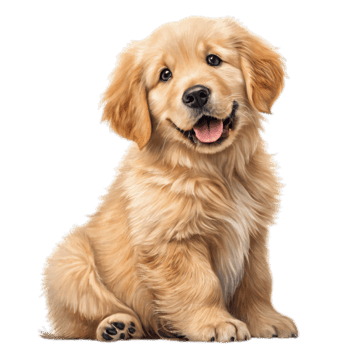


===== Phân tích ảnh bằng OpenAI =====
Trong ảnh, có một chú chó con giống như giống Golden Retriever. Chú chó có bộ lông màu vàng sáng, mềm mại và bông xù, với đôi mắt to và biểu cảm vui vẻ. Chú đang ngồi với tư thế thoải mái, miệng mở ra như đang mỉm cười.

### Phân tích:
- **Đối tượng chính**: Chú chó con.
- **Mối quan hệ**: Chú chó thể hiện sự thân thiện và đáng yêu, có thể tạo cảm giác gần gũi với người xem.

### Kết luận:
Nội dung của ảnh chủ yếu tập trung vào sự dễ thương và vui vẻ của chú chó con, có thể gợi lên cảm xúc tích cực cho người xem.

Token usage: {'prompt_tokens': 8555, 'completion_tokens': 158, 'total_tokens': 8713, 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0}, 'completion_tokens_details': {'reasoning_tokens': 0, 'audio_tokens': 0, 'accepted_prediction_tokens': 0, 'rejected_prediction_tokens': 0}}

===== Phân tích ảnh bằng Xiaomi MiMo =====
❌ Xiaomi MiMo không xử lý được ảnh: 404 Client Error: Not Found for url: https://token-plan-sgp.xiaomimimo.

In [13]:
# ============================================================
# Cell 8 (V2): Test khả năng đọc dữ liệu và hiểu nội dung hình ảnh
# Gửi ảnh base64 theo chuẩn OpenAI-compatible Vision API
# ============================================================
import base64
import mimetypes
from IPython.display import Image as IPImage, display

IMAGE_PATH = ENV_PATH.parent / "documents" / "cho.png"
IMAGE_PROMPT = (
    "Hãy phân tích ảnh này bằng tiếng Việt. Trích xuất mọi văn bản hoặc dữ liệu nhìn thấy, "
    "mô tả các đối tượng chính, mối quan hệ giữa chúng và đưa ra kết luận ngắn về nội dung ảnh."
)


def image_to_data_url(image_path: Path) -> str:
    mime_type = mimetypes.guess_type(image_path.name)[0] or "image/png"
    encoded = base64.b64encode(image_path.read_bytes()).decode("ascii")
    return f"data:{mime_type};base64,{encoded}"


def test_image_understanding_v2(provider, image_path: Path):
    provider_name = provider.get("name", "Unknown provider")
    api_base = provider.get("api_base", "").rstrip("/")
    if not image_path.is_file():
        print(f"❌ Không tìm thấy ảnh: {image_path}")
        return

    payload = {
        "model": provider["model"],
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": IMAGE_PROMPT},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": image_to_data_url(image_path),
                            "detail": "high",
                        },
                    },
                ],
            }
        ],
        "temperature": 0.1,
        "max_tokens": 1000,
    }

    print(f"\n===== Phân tích ảnh bằng {provider_name} =====")
    try:
        response = requests.post(
            f"{api_base}/chat/completions",
            headers=provider_headers(provider),
            json=payload,
            timeout=180,
        )
        response.raise_for_status()
        data = response.json()
        print(data["choices"][0]["message"]["content"])
        usage = data.get("usage", {})
        print(f"\nToken usage: {usage}")
    except requests.RequestException as error:
        print(f"❌ {provider_name} không xử lý được ảnh: {error}")
        if error.response is not None:
            print(error.response.text[:2000])
        print("👉 Provider hoặc model này có thể không hỗ trợ đầu vào hình ảnh.")


print(f"🖼️  Ảnh test: {IMAGE_PATH}")
display(IPImage(filename=str(IMAGE_PATH), width=400))
for provider in PROVIDERS:
    test_image_understanding_v2(provider, IMAGE_PATH)

In [14]:
# ============================================================
# Cell 9: Test lấy dữ liệu và hỏi đáp với file PDF
# Trích xuất text bằng PyMuPDF, sau đó gửi context tới Cloud API
# ============================================================
import fitz  # PyMuPDF

PDF_PATH = ENV_PATH.parent / "documents" / "test1.pdf"
PDF_QUESTION = "Tài liệu này nói về chủ đề gì? Hãy tóm tắt các ý chính và trích dẫn số trang liên quan."
MAX_PDF_PAGES = 10
MAX_CONTEXT_CHARS = 24000


def extract_pdf_text(pdf_path: Path, max_pages=MAX_PDF_PAGES) -> str:
    if not pdf_path.is_file():
        raise FileNotFoundError(f"Không tìm thấy PDF: {pdf_path}")

    page_texts = []
    with fitz.open(pdf_path) as document:
        for page_index in range(min(len(document), max_pages)):
            text = document[page_index].get_text("text").strip()
            if text:
                page_texts.append(f"--- Trang {page_index + 1} ---\n{text}")

    return "\n\n".join(page_texts)[:MAX_CONTEXT_CHARS]


def ask_pdf(provider, pdf_text: str, question: str):
    provider_name = provider.get("name", "Unknown provider")
    messages = [
        {
            "role": "system",
            "content": (
                "Bạn là trợ lý hỏi đáp tài liệu. Chỉ trả lời bằng dữ liệu trong PDF được cung cấp. "
                "Nếu tài liệu không có thông tin cần thiết, hãy nói rõ. Luôn ghi số trang làm bằng chứng."
            ),
        },
        {
            "role": "user",
            "content": f"NỘI DUNG PDF:\n{pdf_text}\n\nCÂU HỎI: {question}",
        },
    ]

    print(f"\n===== Hỏi đáp PDF bằng {provider_name} =====")
    data = chat_messages(provider, messages, max_tokens=1200)
    if data:
        print(data["choices"][0]["message"]["content"])
        usage = data.get("usage", {})
        print(f"\nToken usage: {usage}")


try:
    pdf_text = extract_pdf_text(PDF_PATH)
    print(f"📄 PDF test: {PDF_PATH}")
    print(f"Đã trích xuất {len(pdf_text):,} ký tự từ tối đa {MAX_PDF_PAGES} trang.")
    print(f"Câu hỏi: {PDF_QUESTION}")

    if not pdf_text.strip():
        print("❌ PDF không có text có thể trích xuất. PDF scan cần OCR trước khi hỏi đáp.")
    else:
        for provider in PROVIDERS:
            ask_pdf(provider, pdf_text, PDF_QUESTION)
except Exception as error:
    print(f"❌ Không thể xử lý PDF: {error}")

📄 PDF test: /home/jkl0909/Code/llm/VLLM-PD/documents/test1.pdf
Đã trích xuất 1,774 ký tự từ tối đa 10 trang.
Câu hỏi: Tài liệu này nói về chủ đề gì? Hãy tóm tắt các ý chính và trích dẫn số trang liên quan.

===== Hỏi đáp PDF bằng OpenAI =====
Tài liệu này nói về hệ thống tương tác giọng nói đa ngôn ngữ cho robot hình người Unitree G1, với các yếu tố chính như khả năng tương tác tự nhiên, triển khai trên phần cứng thực tế và các thách thức kỹ thuật liên quan.

**Tóm tắt các ý chính:**

1. **Mục tiêu và vấn đề**:
   - Tạo điều kiện cho tương tác giọng nói tự nhiên, hỗ trợ tiếng Việt và tiếng Nhật trong môi trường nhiều người nói (Trang 2).

2. **Giới hạn hệ thống**:
   - Sử dụng SDK của Unitree cho đầu vào/đầu ra âm thanh, không kiểm soát ALSA trực tiếp, và các hạn chế về đa luồng CUDA (Trang 3).

3. **Kiến trúc hệ thống**:
   - Quy trình từ mic đến nhận diện từ khóa, nhận diện giọng nói (ASR), và chuyển văn bản thành giọng nói (TTS) (Trang 4).

4. **Thách thức kỹ thuật âm thanh**:
   - 